# YOLO — First Detection

### What Is YOLO?

YOLO stands for **You Only Look Once**.

Most earlier detectors scanned an image region by region:

```
Image
↓
Find ~2000 candidate regions
↓
Run classifier on each region
↓
Slow 🐢
```

YOLO passes the entire image through the network **once** and predicts all boxes simultaneously:

```
Image
↓
One CNN pass
↓
All boxes + labels at once
↓
Fast 🐇
```

### How YOLO Works Internally

YOLO divides the image into a grid. Each cell predicts:

```
x, y        ←  object center relative to cell
w, h        ←  bounding box size
confidence  ←  is there an object here?
class probs ←  which of the 80 classes?
```

After predictions, YOLO applies **NMS** (Non-Maximum Suppression) to remove duplicate boxes and keep only the best detection per object.

We built both IoU and NMS from scratch in p02 — that's exactly what's running internally here.

### COCO Dataset — What YOLO Already Knows

YOLOv8 comes with weights pre-trained on **COCO** (Common Objects in Context):

- 330,000 images
- 80 object classes
- Things like: person, car, bicycle, dog, cat, chair, phone, bottle...

This means we don't need to train anything — the model already knows how to detect all 80 classes out of the box.

### YOLOv8 Model Sizes

YOLOv8 comes in different sizes — tradeoff between speed and accuracy:

| Model | Speed | Accuracy | Use Case |
| ----- | ----- | -------- | -------- |
| `yolov8n` | Fastest 🐇 | Lowest | Real-time, low power |
| `yolov8s` | Fast | Good | Balanced |
| `yolov8m` | Medium | Better | When accuracy matters |
| `yolov8l` | Slow | High | Offline processing |
| `yolov8x` | Slowest 🐢 | Highest | Maximum accuracy |

We start with `yolov8n` (nano) — fast, lightweight, good enough for learning.

The first time this runs, ultralytics automatically downloads the weights and caches them. Every run after uses the cached version.

### Setup

In [6]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Load Model

In [7]:
model = YOLO('yolov8n.pt')

`YOLO('yolov8n.pt')` loads the nano model.

First run downloads weights automatically (~6MB). Cached after that.

### What Classes Does This Model Know?

In [8]:
print(f"Total classes: {len(model.names)}")
print()
for id, name in model.names.items():
    print(f"  {id}  {name}")

Total classes: 80

  0  person
  1  bicycle
  2  car
  3  motorcycle
  4  airplane
  5  bus
  6  train
  7  truck
  8  boat
  9  traffic light
  10  fire hydrant
  11  stop sign
  12  parking meter
  13  bench
  14  bird
  15  cat
  16  dog
  17  horse
  18  sheep
  19  cow
  20  elephant
  21  bear
  22  zebra
  23  giraffe
  24  backpack
  25  umbrella
  26  handbag
  27  tie
  28  suitcase
  29  frisbee
  30  skis
  31  snowboard
  32  sports ball
  33  kite
  34  baseball bat
  35  baseball glove
  36  skateboard
  37  surfboard
  38  tennis racket
  39  bottle
  40  wine glass
  41  cup
  42  fork
  43  knife
  44  spoon
  45  bowl
  46  banana
  47  apple
  48  sandwich
  49  orange
  50  broccoli
  51  carrot
  52  hot dog
  53  pizza
  54  donut
  55  cake
  56  chair
  57  couch
  58  potted plant
  59  bed
  60  dining table
  61  toilet
  62  tv
  63  laptop
  64  mouse
  65  remote
  66  keyboard
  67  cell phone
  68  microwave
  69  oven
  70  toaster
  71  sink
  72  ref

`model.names` is a dictionary mapping class ID → class name.

Every detection will return one of these 80 class IDs.

### Run Detection On An Image

In [9]:
IMAGE_PATH = 'images/yolo_test_1.png'

results = model(IMAGE_PATH)


image 1/1 c:\Coding\Python\internship\Pytorch\M6 Video & Motion Recognition\images\yolo_test_1.png: 416x640 2 persons, 1 bicycle, 2 cars, 104.4ms
Speed: 28.9ms preprocess, 104.4ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)


`model(IMAGE_PATH)` runs the full YOLO pipeline:

```
Load image
↓
Resize to model input size
↓
One CNN forward pass
↓
Filter low confidence predictions
↓
Apply NMS
↓
Return results
```

It returns a list — one result per image. Since we passed one image, `results[0]` is our detection.

### Inspect Raw Output

In [16]:
result = results[0]

print(f"Detections found: {len(result.boxes)}")
print()

for box in result.boxes:
    
    class_id   = int(box.cls.item())
    label      = model.names[class_id]
    confidence = box.conf.item()
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    print(f"  {label:<15} conf: {confidence:<10.2f}   box: ({int(x1)}, {int(y1)}, {int(x2)}, {int(y2)})")

Detections found: 5

  bicycle         conf: 0.89         box: (112, 4, 232, 74)
  person          conf: 0.84         box: (244, 67, 274, 155)
  person          conf: 0.81         box: (29, 77, 80, 175)
  car             conf: 0.81         box: (57, 79, 272, 175)
  car             conf: 0.45         box: (0, 110, 36, 170)


#### `result.boxes`

List of all detections that survived NMS.

| Attribute | What It Contains |
| --------- | ---------------- |
| `box.cls` | Class ID (integer) |
| `box.conf` | Confidence score (0→1) |
| `box.xyxy` | Bounding box as `(x1, y1, x2, y2)` in pixels |

#### `.item()`

Converts a single-element tensor to a plain Python number — same pattern we used in Phase 5.

### Visualize Detections

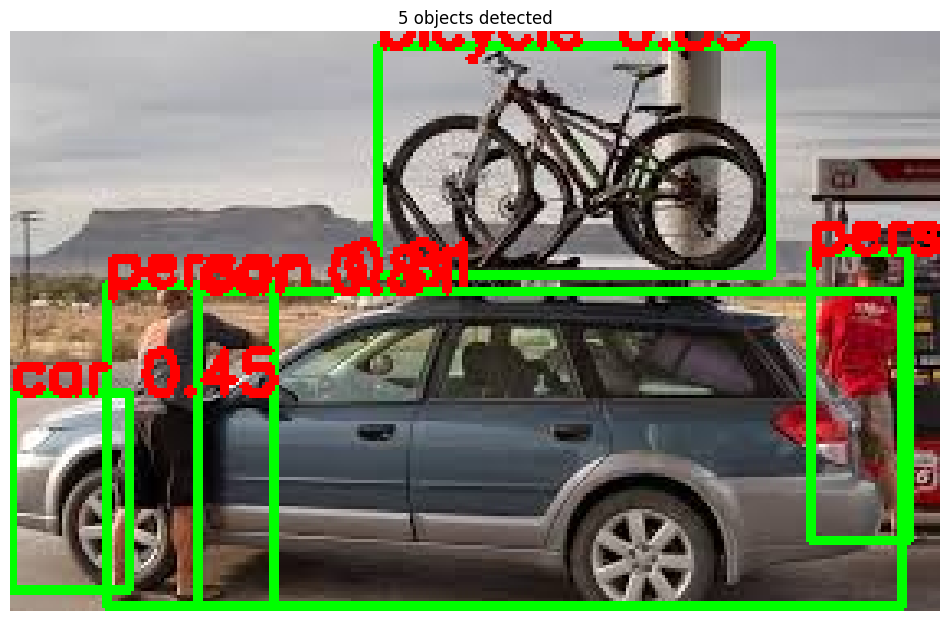

In [19]:
def draw_detections(image_path, results):
    
    frame = cv2.imread(image_path)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    result = results[0]
    
    for box in result.boxes:
        
        class_id   = int(box.cls.item())
        label      = model.names[class_id]
        confidence = box.conf.item()
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        
        # Draw box
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Draw label
        text = f"{label} {confidence:.2f}"
        cv2.putText(frame, text, (x1, y1),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(frame)
    plt.axis('off')
    plt.title(f"{len(result.boxes)} objects detected")
    plt.show()

draw_detections(IMAGE_PATH, results)

### Confidence Threshold

By default YOLO filters out detections below `conf=0.25`.

We can control this:

```python
# Stricter — only high confidence detections
results = model(IMAGE_PATH, conf=0.5)

# Looser — catches more objects but more false positives
results = model(IMAGE_PATH, conf=0.1)
```

This is the same tradeoff as the similarity threshold in face recognition:

| Threshold | Effect |
| --------- | ------ |
| High | Fewer detections, more accurate |
| Low | More detections, more false positives |

### Try Different Thresholds

In [12]:
for conf in [0.1, 0.25, 0.5, 0.75]:
    results = model(IMAGE_PATH, conf=conf, verbose=False)
    print(f"conf={conf}  →  {len(results[0].boxes)} detections")

conf=0.1  →  6 detections
conf=0.25  →  5 detections
conf=0.5  →  4 detections
conf=0.75  →  4 detections


#### `verbose=False`
- suppresses YOLO's console output
- by default YOLO prints detection info every frame
- with verbose=False, output is clean

### ultralytics Built-in Visualization

ultralytics also has a built-in plot function — useful for quick checks:

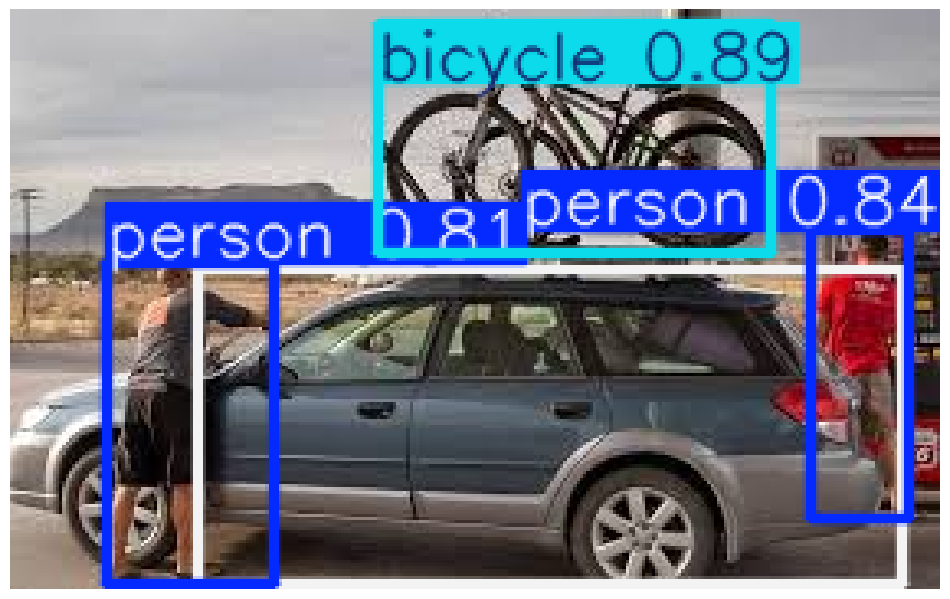

In [ ]:
results = model(IMAGE_PATH, conf=0.5, verbose=False)

annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)   
plt.axis('off')
plt.show()

`results[0].plot()` returns the image with boxes already drawn.

We use our own `draw_detections` function when we need more control — custom colors, filtering specific classes, etc.

We use `.plot()` for quick visual checks.

### Summary

| Concept | What It Means |
| ------- | ------------- |
| `YOLO('yolov8n.pt')` | Load nano model, auto-downloads weights on first run |
| `model(image)` | Run full detection pipeline — one forward pass |
| `result.boxes` | All detections that survived NMS |
| `box.cls` | Class ID → map to name via `model.names` |
| `box.conf` | Confidence score |
| `box.xyxy` | Bounding box corners in pixels |
| `conf=` | Threshold — controls detection sensitivity |

Next up — we move from images to live webcam detection in real-time.